In [1]:
#import libraries
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay


I0000 00:00:1783721898.346829   91919 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783721898.347285   91919 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783721898.383601   91919 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783721899.339083   91919 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
#load data
four_df = pd.read_csv('/home/yvonne_chook/github/207-Summer26-FinalProject-MLModel/Merged_EDA/combined_data/combined_data_4h.csv')

one_df = pd.read_csv('/home/yvonne_chook/github/207-Summer26-FinalProject-MLModel/Merged_EDA/combined_data/combined_data_1h.csv')

- No delay or early departure (0)
- Less than 1 hour delay (1)
- 1–2 hour delay (2)
- 2–3 hour delay (3)
- 3–4 hour delay (4)
- 4–5 hour delay (5)
- 5–6 hour delay (6) 
- More than 6 hour delay (7)
- Flight cancelled (8)

Note to team, there should be a total of 9 outcomes

In [3]:
print(f"Four-hour data shape: {four_df.shape}")
print(f"Four hour data columns: {four_df.columns}")
print(f"One-hour data shape: {one_df.shape}")
print(f"One hour data columns: {one_df.columns}")

Four-hour data shape: (339996, 32)
Four hour data columns: Index(['date', 'scheduled_dep_dt', 'actual_dep_dt', 'carrier_code',
       'destination_airport', 'scheduled_elapsed_time_minutes', 'year',
       'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'outcome',
       'days_until_holiday', 'days_from_holiday', 'year_mfr', 'model',
       'no_seats', 'visibility', 'ceiling_height', 'wind_speed',
       'wind_direction', 'temperature', 'dew_point_temperature',
       'relative_humidity', 'altimeter', 'aircraft_age', 'week_num',
       'temperature_dewpoint_spread', 'airport_delay_average_1h',
       'airport_delay_stddev_1h', 'airport_departures_observed_1h',
       'departure_delay_minutes'],
      dtype='str')
One-hour data shape: (334086, 32)
One hour data columns: Index(['date', 'scheduled_dep_dt', 'actual_dep_dt', 'carrier_code',
       'destination_airport', 'scheduled_elapsed_time_minutes', 'year',
       'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'outcome'

In [4]:
#currently only 8 displayed
four_df["outcome"].unique()

array([0., 1., 2., 8., 3., 4., 6., 5., 7.])

In [5]:
four_df

,date,scheduled_dep_dt,actual_dep_dt,carrier_code,destination_airport,scheduled_elapsed_time_minutes,year,month,day_of_week,is_weekend,...,dew_point_temperature,relative_humidity,altimeter,aircraft_age,week_num,temperature_dewpoint_spread,airport_delay_average_1h,airport_delay_stddev_1h,airport_departures_observed_1h,departure_delay_minutes
0,2022-01-01,2022-01-01 05:25:00,2022-01-01 05:25:00,WN,DEN,145.0,2022.0,1.0,5.0,1,...,5.0,69.0,1012.9,16.0,1,5.6,134.666667,30.746273,3.0,0.0
1,2022-01-01,2022-01-01 05:55:00,2022-01-01 05:52:00,DL,SLC,118.0,2022.0,1.0,5.0,1,...,5.0,69.0,1012.9,3.0,1,5.6,136.250000,24.931573,4.0,-3.0
2,2022-01-01,2022-01-01 06:00:00,2022-01-01 06:14:00,DL,ATL,272.0,2022.0,1.0,5.0,1,...,4.4,68.0,1013.2,20.0,1,5.6,136.250000,24.931573,4.0,14.0
3,2022-01-01,2022-01-01 06:02:00,2022-01-01 05:56:00,UA,LAX,98.0,2022.0,1.0,5.0,1,...,4.4,68.0,1013.2,6.0,1,5.6,141.666667,27.501515,3.0,-6.0
4,2022-01-01,2022-01-01 06:10:00,2022-01-01 07:51:00,DL,MSP,218.0,2022.0,1.0,5.0,1,...,4.4,68.0,1013.2,24.0,1,5.6,149.000000,26.820390,4.0,101.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339991,2026-04-30,2026-04-30 15:17:00,2026-04-30 15:17:00,AS,LAX,92.0,2026.0,4.0,3.0,0,...,9.4,83.0,1015.6,17.0,18,2.8,14.444444,31.939045,27.0,0.0
339992,2026-04-30,2026-04-30 15:17:00,2026-04-30 15:21:00,AA,JFK,342.0,2026.0,4.0,3.0,0,...,9.4,83.0,1015.6,12.0,18,2.8,14.444444,31.939045,27.0,4.0
339993,2026-04-30,2026-04-30 15:20:00,2026-04-30 15:13:00,UA,ORD,273.0,2026.0,4.0,3.0,0,...,9.4,83.0,1015.6,13.0,18,2.8,15.720000,32.858941,25.0,-7.0
339994,2026-04-30,2026-04-30 15:40:00,2026-04-30 17:15:00,WN,SAN,95.0,2026.0,4.0,3.0,0,...,9.4,83.0,1015.6,1.0,18,2.8,21.363636,36.845295,22.0,95.0


In [6]:
one_df

,date,scheduled_dep_dt,actual_dep_dt,carrier_code,destination_airport,scheduled_elapsed_time_minutes,year,month,day_of_week,is_weekend,...,dew_point_temperature,relative_humidity,altimeter,aircraft_age,week_num,temperature_dewpoint_spread,airport_delay_average_1h,airport_delay_stddev_1h,airport_departures_observed_1h,departure_delay_minutes
0,2022-01-01,2022-01-01 05:25:00,2022-01-01 05:25:00,WN,DEN,145.0,2022.0,1.0,5.0,1,...,5.0,74.0,1014.6,16.0,1,4.4,0.000000,0.000000,0.0,0.0
1,2022-01-01,2022-01-01 05:55:00,2022-01-01 05:52:00,DL,SLC,118.0,2022.0,1.0,5.0,1,...,5.0,74.0,1014.6,3.0,1,4.4,0.000000,0.000000,0.0,-3.0
2,2022-01-01,2022-01-01 06:00:00,2022-01-01 06:14:00,DL,ATL,272.0,2022.0,1.0,5.0,1,...,5.0,77.0,1015.6,20.0,1,3.9,0.000000,0.000000,0.0,14.0
3,2022-01-01,2022-01-01 06:02:00,2022-01-01 05:56:00,UA,LAX,98.0,2022.0,1.0,5.0,1,...,5.0,77.0,1015.6,6.0,1,3.9,0.000000,0.000000,0.0,-6.0
4,2022-01-01,2022-01-01 06:10:00,2022-01-01 07:51:00,DL,MSP,218.0,2022.0,1.0,5.0,1,...,5.0,77.0,1015.6,24.0,1,3.9,0.000000,0.000000,0.0,101.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334081,2026-04-30,2026-04-30 12:37:00,2026-04-30 13:17:00,DL,MSP,223.0,2026.0,4.0,3.0,0,...,9.4,83.0,1015.6,9.0,18,2.8,18.904762,36.750381,21.0,40.0
334082,2026-04-30,2026-04-30 12:40:00,2026-04-30 12:43:00,UA,SNA,102.0,2026.0,4.0,3.0,0,...,9.4,83.0,1015.6,3.0,18,2.8,21.363636,36.845295,22.0,3.0
334083,2026-04-30,2026-04-30 12:45:00,2026-04-30 12:45:00,UA,IAD,312.0,2026.0,4.0,3.0,0,...,9.4,83.0,1015.6,12.0,18,2.8,25.714286,39.733038,21.0,0.0
334084,2026-04-30,2026-04-30 12:45:00,2026-04-30 13:09:00,UA,DEN,164.0,2026.0,4.0,3.0,0,...,9.4,83.0,1015.6,2.0,18,2.8,25.714286,39.733038,21.0,24.0


In [7]:
#analyze data

four_df.describe()

,scheduled_elapsed_time_minutes,year,month,day_of_week,is_weekend,sched_dep_hour,outcome,days_until_holiday,days_from_holiday,year_mfr,...,dew_point_temperature,relative_humidity,altimeter,aircraft_age,week_num,temperature_dewpoint_spread,airport_delay_average_1h,airport_delay_stddev_1h,airport_departures_observed_1h,departure_delay_minutes
count,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,...,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000,339996.000000
mean,217.008135,2023.682176,6.384949,2.973079,0.274812,12.951391,0.511624,45.900308,24.271206,2011.126740,...,9.649758,76.916996,1016.243696,12.555436,25.992944,4.250026,13.573540,22.199175,11.330298,10.284053
std,98.363863,1.189761,3.285837,2.003803,0.446420,5.497408,0.877542,36.679803,19.256173,9.164792,...,3.318651,12.444813,4.690542,9.079588,14.365662,2.853834,37.162049,39.265885,8.420433,40.130938
min,48.000000,2022.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1970.000000,...,-7.800000,10.000000,989.500000,0.000000,1.000000,0.000000,-21.000000,0.000000,0.000000,-92.000000
25%,110.000000,2023.000000,4.000000,1.000000,0.000000,8.000000,0.000000,17.000000,9.000000,2002.000000,...,7.800000,70.000000,1013.200000,5.000000,14.000000,2.200000,-1.400000,2.516611,2.000000,-6.000000
50%,224.000000,2024.000000,6.000000,3.000000,0.000000,12.000000,0.000000,36.000000,19.000000,2014.000000,...,10.000000,79.000000,1015.900000,10.000000,26.000000,3.800000,0.470588,9.671445,12.000000,-2.000000
75%,319.000000,2025.000000,9.000000,5.000000,1.000000,17.000000,1.000000,66.000000,36.000000,2019.000000,...,12.200000,86.000000,1019.000000,21.000000,38.000000,5.500000,14.500000,28.070664,17.000000,9.000000
max,386.000000,2026.000000,12.000000,6.000000,1.000000,23.000000,8.000000,148.000000,74.000000,2026.000000,...,18.900000,100.000000,1034.900000,56.000000,53.000000,35.600000,1158.000000,1120.551606,69.000000,1101.000000


In [8]:
#split train validation and test data

#Do this for 2 hr data
four_train_df = four_df[
    (four_df["date"] >= "2022-01-01") &
    (four_df["date"] <= "2024-12-31")
]

four_validation_df = four_df[
    (four_df["date"] >= "2024-01-01") &
    (four_df["date"] <= "2024-12-31")
]

four_test_df = four_df[
    (four_df["date"] >= "2025-01-01") &
    (four_df["date"] <= "2026-06-09")
]

#Do this for 4 hr data
one_train_df = one_df[
    (one_df["date"] >= "2022-01-01") &
    (one_df["date"] <= "2024-12-31")
]

one_validation_df = one_df[
    (one_df["date"] >= "2024-01-01") &
    (one_df["date"] <= "2024-12-31")
]

one_test_df = one_df[
    (one_df["date"] >= "2025-01-01") &
    (one_df["date"] <= "2026-06-09")
]

#print shape of each
print("2hr data:")
print("Train shape:", four_train_df.shape)
print("Validation shape:", four_validation_df.shape)
print("Test shape:", four_test_df.shape)

print("\n1hr data:")
print("Train shape:", one_train_df.shape)
print("Validation shape:", one_validation_df.shape)
print("Test shape:", one_test_df.shape)

2hr data:
Train shape: (240324, 32)
Validation shape: (86039, 32)
Test shape: (99672, 32)

1hr data:
Train shape: (236106, 32)
Validation shape: (84531, 32)
Test shape: (97980, 32)


In [9]:
four_train_df.columns

Index(['date', 'scheduled_dep_dt', 'actual_dep_dt', 'carrier_code',
       'destination_airport', 'scheduled_elapsed_time_minutes', 'year',
       'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'outcome',
       'days_until_holiday', 'days_from_holiday', 'year_mfr', 'model',
       'no_seats', 'visibility', 'ceiling_height', 'wind_speed',
       'wind_direction', 'temperature', 'dew_point_temperature',
       'relative_humidity', 'altimeter', 'aircraft_age', 'week_num',
       'temperature_dewpoint_spread', 'airport_delay_average_1h',
       'airport_delay_stddev_1h', 'airport_departures_observed_1h',
       'departure_delay_minutes'],
      dtype='str')

In [10]:
#feature selection

numeric_features = [
    "scheduled_elapsed_time_minutes",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sched_dep_hour",
    "days_until_holiday",
    "days_from_holiday",
    "year_mfr",
    "no_seats",
    "visibility",
    "ceiling_height",
    "wind_speed",
    "wind_direction",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "altimeter",
    "aircraft_age",
    "week_num",
    "temperature_dewpoint_spread",
    "airport_delay_average_1h",
    "airport_delay_stddev_1h",
    "airport_departures_observed_1h"
]

categorical_features = [
    "carrier_code",
    "destination_airport",
    "model"
]

features = numeric_features + categorical_features

target = "departure_delay_minutes"

Not included in features: date, schedueld_dep_dt, actual_dep_dt, outcome, departure_delay_minutes. because this data is already extracted in the other fields or they are related to the outcome.

**2 hour linear regression baseline**

In [11]:
# create X and y
four_X_train = four_train_df[features]
four_y_train = four_train_df[target]

four_X_val = four_validation_df[features]
four_y_val = four_validation_df[target]

four_X_test = four_test_df[features]
four_y_test = four_test_df[target]



In [12]:
#building prepreocessing pipeline
# scale features
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# fill missing values and one-hot encode
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

# Apply the correct transformation to each column type
preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

In [13]:
# Fit only on training data
four_X_train_processed = preprocessor.fit_transform(four_X_train)

# Apply the same fitted transformations to validation and test data
four_X_val_processed = preprocessor.transform(four_X_val)
four_X_test_processed = preprocessor.transform(four_X_test)

print("Training shape:", four_X_train_processed.shape)
print("Validation shape:", four_X_val_processed.shape)
print("Test shape:", four_X_test_processed.shape)

Training shape: (240324, 175)
Validation shape: (86039, 175)
Test shape: (99672, 175)


/home/yvonne_chook/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [14]:
#build model
def build_model(num_features, learning_rate):
    tf.keras.backend.clear_session()
    tf.random.set_seed(0)

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(num_features,)),
        tf.keras.layers.Dense(units=1, use_bias=True)
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

E0000 00:00:1783721903.314164   91919 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1783721903.314728   91981 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783721903.331390   91919 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


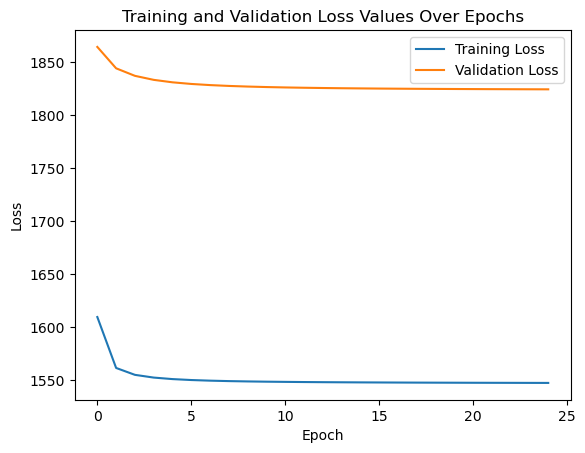

In [15]:
# train model

four_model = build_model(
    num_features=four_X_train_processed.shape[1],
    learning_rate=0.001
)

four_trained_model = four_model.fit(
    four_X_train_processed,
    four_y_train,
    validation_data=(four_X_val_processed, four_y_val),
    epochs=25,
    batch_size=32,
    verbose = 0
)

#plot output
#plot
plt.plot(four_trained_model.history['loss'], label="Training Loss")
plt.plot(four_trained_model.history['val_loss'], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Values Over Epochs")
plt.legend()
plt.show()


In [16]:
#Obtain weight and bias
four_weights, four_bias = four_model.layers[0].get_weights()

#calulate train and test mse

four_train_mse, four_train_mae = four_model.evaluate(
    four_X_train_processed,
    four_y_train,
    verbose=0
)

# Calculate test MSE and MAE
four_test_mse, four_test_mae = four_model.evaluate(
    four_X_test_processed,
    four_y_test,
    verbose=0
)

# Learned parameters
print(f"Learned Weights:\n{four_weights}")
print(f"\nLearned Bias:\n{four_bias}")

print(f"Train MSE: {four_train_mse:.3f}")
print(f"Train MAE: {four_train_mae:.3f}")

print(f"Test MSE: {four_test_mse:.3f}")
print(f"Test MAE: {four_test_mae:.3f}")

print(f"Difference between test and train MSE: {abs(four_train_mse - four_test_mse):.3f}")

Learned Weights:
[[ 5.4820561e-01]
 [ 1.2948987e+00]
 [-1.4245720e+00]
 [ 1.3132770e+00]
 [-3.3236346e-01]
 [-9.8492092e-01]
 [-1.9287696e+00]
 [-1.3881375e-01]
 [-4.0940213e-01]
 [ 1.7143404e+00]
 [-4.8001939e-01]
 [-1.3567343e+00]
 [ 1.5474300e-01]
 [-6.7468029e-01]
 [-1.1394818e+00]
 [-8.4130937e-01]
 [ 1.1916084e+00]
 [-1.7670338e+00]
 [ 5.6150317e-01]
 [-6.7798269e-01]
 [-5.1966637e-02]
 [-1.3887544e-01]
 [ 1.4567357e+00]
 [ 3.1567657e+00]
 [ 1.4963319e+00]
 [-2.2799399e+00]
 [ 1.9962174e+00]
 [ 7.5712714e+00]
 [ 4.7799018e-01]
 [ 1.3432422e-01]
 [ 8.3155842e+00]
 [-1.8724008e+00]
 [-4.8873171e-01]
 [-1.7777143e+00]
 [ 3.2419159e+00]
 [-1.1032369e+00]
 [-3.1978188e+00]
 [ 2.3006906e-01]
 [-1.7323899e+00]
 [-1.8504515e+00]
 [-1.3379155e+00]
 [ 1.2642210e+00]
 [ 2.0265751e+00]
 [-1.8723149e+00]
 [-3.8103802e+00]
 [-1.1062216e+00]
 [ 1.2697194e+00]
 [ 5.8982468e+00]
 [-6.7358166e-01]
 [ 3.6007501e-03]
 [ 5.9601808e-01]
 [ 3.2334788e+00]
 [-1.8315876e+00]
 [-2.0905268e+00]
 [ 5.118942

In [17]:
# Predict class probabilities
four_y_pred = four_model.predict(
    four_X_test_processed,
    verbose=0
).flatten()

# Convert actual values to a four-dimensional array
four_y_test_array = np.asarray(four_y_test).flatten()

# Create prediction results table
four_prediction_results = pd.DataFrame({
    "Actual Delay": four_y_test_array,
    "Predicted Delay": four_y_pred
})

# Calculate prediction errors
four_prediction_results["Prediction Error"] = (
    four_prediction_results["Predicted Delay"]
    - four_prediction_results["Actual Delay"]
)

four_prediction_results["Absolute Error"] = (
    four_prediction_results["Prediction Error"].abs()
)

four_prediction_results.head(20)

,Actual Delay,Predicted Delay,Prediction Error,Absolute Error
0,-6.0,18.670429,24.670429,24.670429
1,0.0,19.326118,19.326118,19.326118
2,6.0,19.217363,13.217363,13.217363
3,45.0,13.265759,-31.734241,31.734241
4,480.0,22.555065,-457.444935,457.444935
5,-6.0,16.327929,22.327929,22.327929
6,-11.0,17.334312,28.334312,28.334312
7,-8.0,11.911466,19.911466,19.911466
8,-10.0,18.230946,28.230946,28.230946
9,-5.0,20.906536,25.906536,25.906536


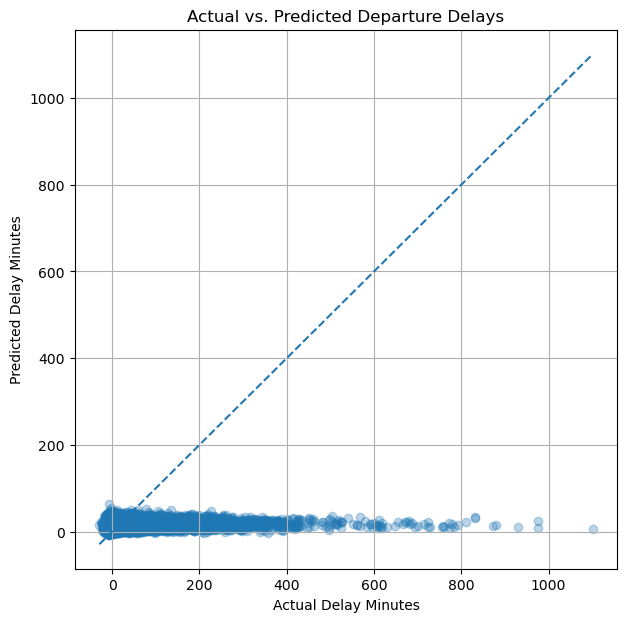

In [18]:
plt.figure(figsize=(7, 7))

plt.scatter(
    four_y_test_array,
    four_y_pred,
    alpha=0.3
)

minimum = min(four_y_test_array.min(), four_y_pred.min())
maximum = max(four_y_test_array.max(), four_y_pred.max())

# Perfect-prediction reference line
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Delay Minutes")
plt.ylabel("Predicted Delay Minutes")
plt.title("Actual vs. Predicted Departure Delays")
plt.grid()
plt.show()

**1 hour linear regression**

In [19]:
# create X and y
one_X_train = one_train_df[features]
one_y_train = one_train_df[target]

one_X_val = one_validation_df[features]
one_y_val = one_validation_df[target]

one_X_test = one_test_df[features]
one_y_test = one_test_df[target]

# scale features
one_X_train_processed = preprocessor.fit_transform(one_X_train)

# Apply the same fitted transformations to validation and test data
one_X_val_processed = preprocessor.transform(one_X_val)
one_X_test_processed = preprocessor.transform(one_X_test)

print("Training shape:", one_X_train_processed.shape)
print("Validation shape:", one_X_val_processed.shape)
print("Test shape:", one_X_test_processed.shape)

Training shape: (236106, 175)
Validation shape: (84531, 175)
Test shape: (97980, 175)


/home/yvonne_chook/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


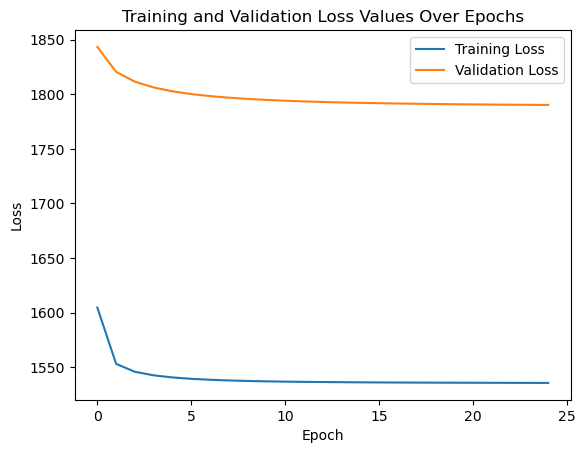

In [20]:
# train model

one_model = build_model(
    num_features=one_X_train_processed.shape[1],
    learning_rate=0.001
)

one_trained_model = one_model.fit(
    one_X_train_processed,
    one_y_train,
    validation_data=(one_X_val_processed, one_y_val),
    epochs=25,
    batch_size=32,
    verbose = 0
)

#plot output
#plot
plt.plot(one_trained_model.history['loss'], label="Training Loss")
plt.plot(one_trained_model.history['val_loss'], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Values Over Epochs")
plt.legend()
plt.show()

In [21]:
#Obtain weight and bias
one_weights, one_bias = one_model.layers[0].get_weights()

#calulate train and test mse

one_train_mse, one_train_mae = one_model.evaluate(
    one_X_train_processed,
    one_y_train,
    verbose=0
)

# Calculate test MSE and MAE
one_test_mse, one_test_mae = one_model.evaluate(
    one_X_test_processed,
    one_y_test,
    verbose=0
)

# Learned parameters
print(f"Learned Weights:\n{one_weights}")
print(f"\nLearned Bias:\n{one_bias}")

print(f"Train MSE: {one_train_mse:.3f}")
print(f"Train MAE: {one_train_mae:.3f}")

print(f"Test MSE: {one_test_mse:.3f}")
print(f"Test MAE: {one_test_mae:.3f}")

print(f"Difference between test and train MSE: {abs(one_train_mse - one_test_mse):.3f}")

Learned Weights:
[[ 2.8881624e-01]
 [ 9.1988558e-01]
 [-1.2954056e+00]
 [ 9.9897820e-01]
 [-2.6992759e-01]
 [ 5.9618145e-01]
 [-1.6893578e+00]
 [-4.3162771e-02]
 [-4.9585685e-01]
 [ 1.6189955e+00]
 [-2.7843827e-01]
 [-1.1484023e+00]
 [ 3.2388961e-01]
 [-1.0570568e+00]
 [-1.0178630e+00]
 [-7.8589833e-01]
 [ 1.0872843e+00]
 [-1.6736778e+00]
 [ 7.2381359e-01]
 [-7.0844418e-01]
 [-7.1045578e-02]
 [ 5.7020617e+00]
 [-2.2946632e+00]
 [ 2.3924093e+00]
 [ 1.2250012e+00]
 [-2.3332200e+00]
 [ 2.0753188e+00]
 [ 7.7324157e+00]
 [-9.3151426e-01]
 [ 3.7747082e-01]
 [ 8.8070879e+00]
 [-3.3418685e-01]
 [-5.6338027e-02]
 [-1.3770533e+00]
 [ 3.9033487e+00]
 [ 1.3082236e-01]
 [-2.0649562e+00]
 [ 3.3699024e-01]
 [-2.4420202e+00]
 [-2.6037097e+00]
 [-2.9538876e-01]
 [ 1.5933741e+00]
 [ 1.1454529e+00]
 [-2.4520416e+00]
 [-2.6713145e+00]
 [-2.9876158e+00]
 [ 1.3419874e+00]
 [ 5.5753884e+00]
 [-9.8309612e-01]
 [-5.9316909e-01]
 [ 4.1090047e-01]
 [ 3.2932987e+00]
 [-7.5652736e-01]
 [-5.8433276e-01]
 [ 3.319531

In [22]:
# Predict class probabilities
one_y_pred = one_model.predict(
    one_X_test_processed,
    verbose=0
).flatten()

# Convert actual values to a one-dimensional array
one_y_test_array = np.asarray(one_y_test).flatten()

# Create prediction results table
one_prediction_results = pd.DataFrame({
    "Actual Delay": one_y_test_array,
    "Predicted Delay": one_y_pred
})

# Calculate prediction errors
one_prediction_results["Prediction Error"] = (
    one_prediction_results["Predicted Delay"]
    - one_prediction_results["Actual Delay"]
)

one_prediction_results["Absolute Error"] = (
    one_prediction_results["Prediction Error"].abs()
)

one_prediction_results.head(20)

,Actual Delay,Predicted Delay,Prediction Error,Absolute Error
0,-11.0,7.280551,18.280551,18.280551
1,-6.0,6.413800,12.413800,12.413800
2,480.0,12.368772,-467.631228,467.631228
3,-8.0,5.303108,13.303108,13.303108
4,-10.0,12.575244,22.575244,22.575244
5,-5.0,15.600636,20.600636,20.600636
6,14.0,9.506030,-4.493970,4.493970
7,-4.0,8.616068,12.616068,12.616068
8,70.0,8.066621,-61.933379,61.933379
9,-7.0,8.490829,15.490829,15.490829


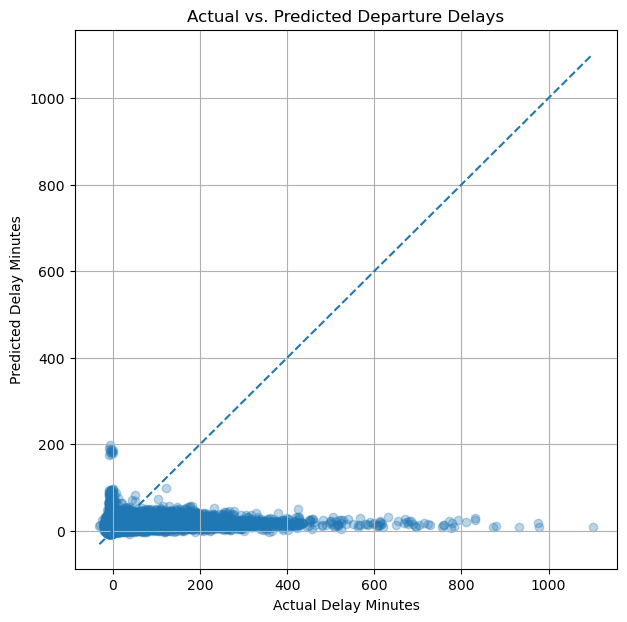

In [23]:
plt.figure(figsize=(7, 7))

plt.scatter(
    one_y_test_array,
    one_y_pred,
    alpha=0.3
)

minimum = min(one_y_test_array.min(), one_y_pred.min())
maximum = max(one_y_test_array.max(), one_y_pred.max())

# Perfect-prediction reference line
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Delay Minutes")
plt.ylabel("Predicted Delay Minutes")
plt.title("Actual vs. Predicted Departure Delays")
plt.grid()
plt.show()

**LOGISTIC REGRESSION**

In [24]:
#define features
target = "outcome"

**4hr Logistic Regression**

In [25]:
four_X_train = four_train_df[features]
four_y_train = four_train_df[target]

four_X_val = four_validation_df[features]
four_y_val = four_validation_df[target]

four_X_test = four_test_df[features]
four_y_test = four_test_df[target]

In [26]:


four_X_train_processed = preprocessor.fit_transform(four_X_train)

four_X_val_processed = preprocessor.transform(four_X_val)

four_X_test_processed = preprocessor.transform(four_X_test)

#check sahpe

print("Train shape:", four_X_train_processed.shape)
print("Validation shape:", four_X_val_processed.shape)
print("Test shape:", four_X_test_processed.shape)

Train shape: (240324, 175)
Validation shape: (86039, 175)
Test shape: (99672, 175)


/home/yvonne_chook/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [27]:
#build model

def build_model(num_features, learning_rate):
    """Return a simple multiclass logistic regression model using Keras."""

    tf.keras.backend.clear_session()
    tf.random.set_seed(0)

    model = tf.keras.Sequential()

    model.add(tf.keras.Input(shape=(num_features,), name="Input"))

    model.add(tf.keras.layers.Dense(
        units=9,
        use_bias=True,
        activation="softmax",
        kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.01),
        bias_initializer=tf.keras.initializers.RandomNormal(stddev=0.01),
        name="Output"
    ))

    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
        metrics=["accuracy"]
    )

    return model

In [28]:
#train

four_model = build_model(
    num_features=four_X_train_processed.shape[1],
    learning_rate=0.01
)

four_trained_model = four_model.fit(
    four_X_train_processed,
    four_y_train,
    validation_data=(four_X_val_processed, four_y_val),
    epochs=25,
    batch_size=32,
    verbose=0
)

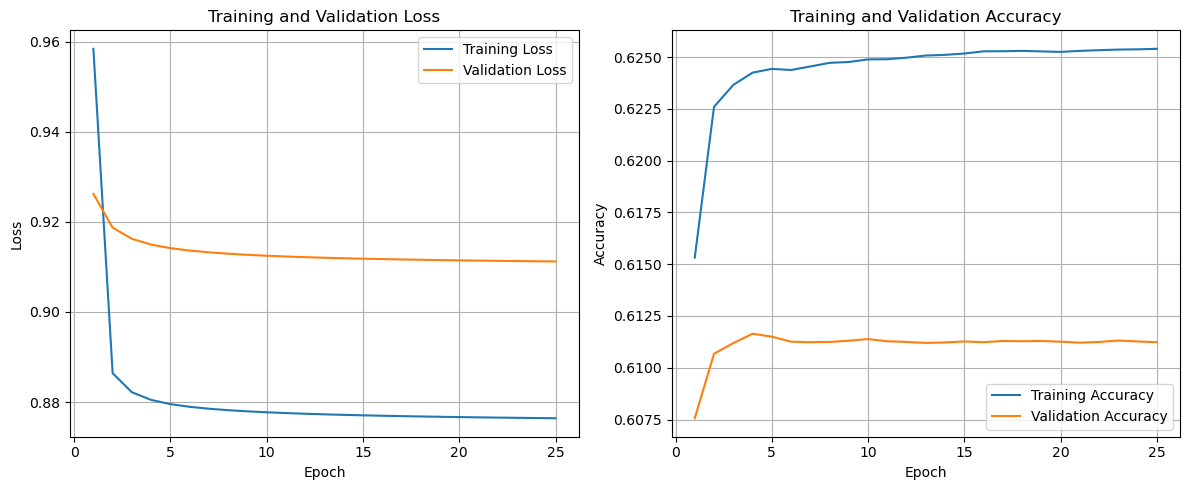

In [29]:
#plot

# Get number of epochs actually trained
num_epochs = len(four_trained_model.history["loss"])
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, four_trained_model.history["loss"], label="Training Loss")
plt.plot(epochs, four_trained_model.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, four_trained_model.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, four_trained_model.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [30]:
four_train_loss, four_train_acc = four_model.evaluate(
    four_X_train_processed,
    four_y_train,
    verbose=0
)

four_val_loss, four_val_acc = four_model.evaluate(
    four_X_val_processed,
    four_y_val,
    verbose=0
)

four_test_loss, four_test_acc = four_model.evaluate(
    four_X_test_processed,
    four_y_test,
    verbose=0
)

print(f"Train Loss: {four_train_loss:.3f}")
print(f"Train Accuracy: {four_train_acc:.3f}")

print(f"\nValidation Loss: {four_val_loss:.3f}")
print(f"Validation Accuracy: {four_val_acc:.3f}")

print(f"\nTest Loss: {four_test_loss:.3f}")
print(f"Test Accuracy: {four_test_acc:.3f}")

Train Loss: 0.876
Train Accuracy: 0.625

Validation Loss: 0.911
Validation Accuracy: 0.611

Test Loss: 0.881
Test Accuracy: 0.633


In [31]:
# Predict class probabilities
four_y_pred_prob = four_model.predict(
    four_X_test_processed,
    verbose=0
)

# Select the class with the highest probability
four_y_pred_class = np.argmax(four_y_pred_prob, axis=1)

# Convert actual labels to a NumPy array
four_y_test_array = np.asarray(four_y_test).flatten()

# Create prediction results table
four_prediction_results = pd.DataFrame({
    "Actual Class": four_y_test_array,
    "Predicted Class": four_y_pred_class,
    "Prediction Confidence": np.max(four_y_pred_prob, axis=1)
})

# Check whether each prediction was correct
four_prediction_results["Correct Prediction"] = (
    four_prediction_results["Actual Class"]
    == four_prediction_results["Predicted Class"]
)

four_prediction_results.head(20)

,Actual Class,Predicted Class,Prediction Confidence,Correct Prediction
0,0.0,0,0.700633,True
1,0.0,0,0.701377,True
2,1.0,0,0.594439,False
3,1.0,0,0.719313,False
4,7.0,0,0.442324,False
5,0.0,0,0.584599,True
6,0.0,0,0.545672,True
7,0.0,0,0.698689,True
8,0.0,0,0.630519,True
9,0.0,0,0.689655,True


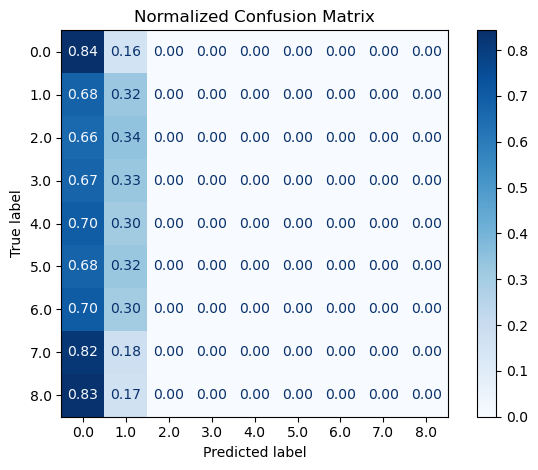

In [32]:
ConfusionMatrixDisplay.from_predictions(
    four_y_test_array,
    four_y_pred_class,
    cmap="Blues",
    normalize="true",
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

**1 hour multiclass classification**

In [33]:
one_X_train = one_train_df[features]
one_y_train = one_train_df[target]
one_X_val = one_validation_df[features]
one_y_val = one_validation_df[target]

one_X_test = one_test_df[features]
one_y_test = one_test_df[target]

In [34]:
#preprocessing
one_X_train_processed = preprocessor.fit_transform(one_X_train)

one_X_val_processed = preprocessor.transform(one_X_val)

one_X_test_processed = preprocessor.transform(one_X_test)

#check sahpe

print("Train shape:", one_X_train_processed.shape)
print("Validation shape:", one_X_val_processed.shape)
print("Test shape:", one_X_test_processed.shape)

Train shape: (236106, 175)
Validation shape: (84531, 175)
Test shape: (97980, 175)


/home/yvonne_chook/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [35]:
#build and train model
one_model = build_model(
    num_features=one_X_train_processed.shape[1],
    learning_rate=0.01
)

one_trained_model = one_model.fit(
    one_X_train_processed,
    one_y_train,
    validation_data=(one_X_val_processed, one_y_val),
    epochs=25,
    batch_size=32,
    verbose=0
)

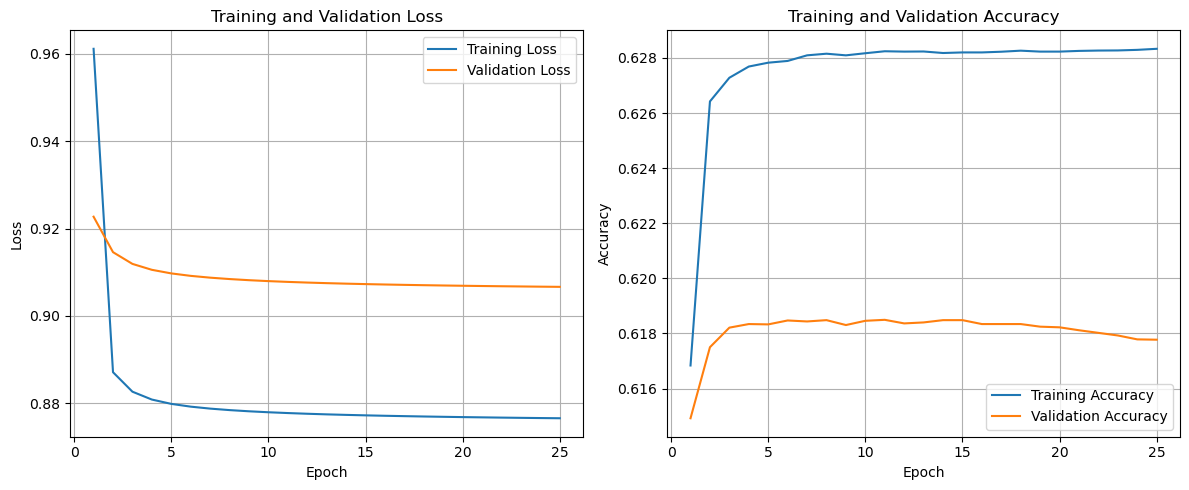

In [36]:
#plot

# Get number of epochs actually trained
num_epochs = len(one_trained_model.history["loss"])
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, one_trained_model.history["loss"], label="Training Loss")
plt.plot(epochs, one_trained_model.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, one_trained_model.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, one_trained_model.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [37]:
one_train_loss, one_train_acc = one_model.evaluate(
    one_X_train_processed,
    one_y_train,
    verbose=0
)

one_val_loss, one_val_acc = one_model.evaluate(
    one_X_val_processed,
    one_y_val,
    verbose=0
)

one_test_loss, one_test_acc = one_model.evaluate(
    one_X_test_processed,
    one_y_test,
    verbose=0
)

print(f"Train Loss: {one_train_loss:.3f}")
print(f"Train Accuracy: {one_train_acc:.3f}")

print(f"\nValidation Loss: {one_val_loss:.3f}")
print(f"Validation Accuracy: {one_val_acc:.3f}")

print(f"\nTest Loss: {one_test_loss:.3f}")
print(f"Test Accuracy: {one_test_acc:.3f}")

Train Loss: 0.876
Train Accuracy: 0.628

Validation Loss: 0.907
Validation Accuracy: 0.618

Test Loss: 0.873
Test Accuracy: 0.652


In [38]:
# Predict class probabilities
one_y_pred_prob = one_model.predict(
    one_X_test_processed,
    verbose=0
)

# Select the class with the highest probability
one_y_pred_class = np.argmax(one_y_pred_prob, axis=1)

# Convert actual labels to a NumPy array
one_y_test_array = np.asarray(one_y_test).flatten()

# Create prediction results table
one_prediction_results = pd.DataFrame({
    "Actual Class": one_y_test_array,
    "Predicted Class": one_y_pred_class,
    "Prediction Confidence": np.max(one_y_pred_prob, axis=1)
})

# Check whether each prediction was correct
one_prediction_results["Correct Prediction"] = (
    one_prediction_results["Actual Class"]
    == one_prediction_results["Predicted Class"]
)

one_prediction_results.head(20)

,Actual Class,Predicted Class,Prediction Confidence,Correct Prediction
0,0.0,0,0.747302,True
1,0.0,0,0.776744,True
2,7.0,0,0.657928,False
3,0.0,0,0.802629,True
4,0.0,0,0.737350,True
5,0.0,0,0.753138,True
6,1.0,0,0.744031,False
7,0.0,0,0.740398,True
8,2.0,0,0.783766,False
9,0.0,0,0.776958,True


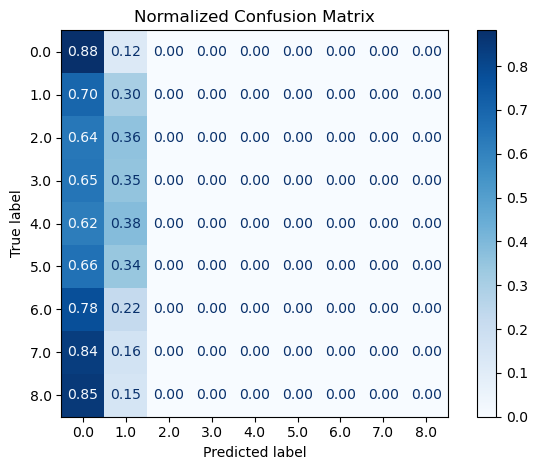

In [39]:
ConfusionMatrixDisplay.from_predictions(
    one_y_test_array,
    one_y_pred_class,
    cmap="Blues",
    normalize="true",
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()